# 103: 文・段落境界チャンキング

Notebook 101 で準備した記事データを使い、**文・段落・セクション境界を考慮した**チャンキング戦略を評価する。
102 の最良固定長結果と比較し、境界考慮の効果を定量化する。

## チャンキング戦略
1. **文グリーディ**: 文を詰めて max_tokens 以内のチャンクを作成
2. **文グリーディ + オーバーラップ**: 末尾N文を次チャンクの先頭に引き継ぐ
3. **段落ベース**: `\n\n` で段落分割、短い段落はマージ、長い段落は文境界で分割
4. **セクション考慮**: Wikipedia の `==見出し==` を境界として使用

## モデル
- `intfloat/multilingual-e5-base` (768d) — max_tokens: [256, 384, 512]
- `Qwen/Qwen3-Embedding-0.6B` (1024d) — max_tokens: [512, 1024, 2048]

## 評価指標
- Recall@10, MRR, ADS (AUC-ROC), IIG

In [2]:
import gc, os, pickle, re, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer
from tqdm.auto import tqdm
sys.path.insert(0, "../src")

SEED = 42
DATA_DIR = "../data"

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def compute_retrieval_metrics(embeddings, article_ids, k=10, n_queries=1000):
    n = len(embeddings)
    rng = np.random.default_rng(SEED)
    query_ids = rng.choice(n, min(n_queries, n), replace=False)
    recalls, mrrs = [], []
    for qid in query_ids:
        same_art = np.where((article_ids == article_ids[qid]) & (np.arange(n) != qid))[0]
        if len(same_art) == 0:
            continue
        sims = embeddings[qid] @ embeddings.T
        sims[qid] = -2.0
        topk_ids = np.argsort(sims)[-k:][::-1]
        found = len(set(same_art) & set(topk_ids))
        recalls.append(found / min(len(same_art), k))
        rr = 0.0
        for rank, idx in enumerate(topk_ids, 1):
            if idx in same_art:
                rr = 1.0 / rank
                break
        mrrs.append(rr)
    return {f"Recall@{k}": float(np.mean(recalls)), "MRR": float(np.mean(mrrs)), "n_queries": len(recalls)}

def compute_ads(embeddings, article_ids, n_sample_pairs=50000):
    n = len(embeddings)
    rng = np.random.default_rng(SEED)
    idx1 = rng.choice(n, n_sample_pairs, replace=True)
    idx2 = rng.choice(n, n_sample_pairs, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    same_article = (article_ids[idx1] == article_ids[idx2]).astype(int)
    ads = roc_auc_score(same_article, cos_sims)
    intra_mask = same_article == 1
    inter_mask = same_article == 0
    intra_mean = float(np.mean(cos_sims[intra_mask])) if intra_mask.sum() > 0 else 0.0
    inter_mean = float(np.mean(cos_sims[inter_mask])) if inter_mask.sum() > 0 else 0.0
    return {"ADS (AUC)": ads, "IIG": intra_mean - inter_mean}

print("Setup complete.")

Setup complete.


In [3]:
def chunk_by_sentence(text, tokenizer, max_tokens, overlap_sentences=0, lang="ja"):
    """文境界でチャンク分割"""
    if lang == "ja":
        sentences = re.split(r"(?<=[。！？\n])", text)
    else:
        sentences = re.split(r"(?<=[.!?\n])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    if not sentences:
        return []
    chunks = []
    current_sents = []
    current_tokens = 0
    for sent in sentences:
        sent_tokens = len(tokenizer.encode(sent, add_special_tokens=False))
        if current_tokens + sent_tokens > max_tokens and current_sents:
            chunks.append("".join(current_sents) if lang == "ja" else " ".join(current_sents))
            if overlap_sentences > 0 and len(current_sents) > overlap_sentences:
                carry = current_sents[-overlap_sentences:]
                current_sents = carry
                current_tokens = sum(len(tokenizer.encode(s, add_special_tokens=False)) for s in carry)
            else:
                current_sents = []
                current_tokens = 0
        current_sents.append(sent)
        current_tokens += sent_tokens
    if current_sents:
        chunks.append("".join(current_sents) if lang == "ja" else " ".join(current_sents))
    return chunks


def chunk_by_paragraph(text, tokenizer, max_tokens, lang="ja"):
    """段落ベースでチャンク分割"""
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    if not paragraphs:
        return []
    chunks = []
    current_paras = []
    current_tokens = 0
    for para in paragraphs:
        para_tokens = len(tokenizer.encode(para, add_special_tokens=False))
        if para_tokens > max_tokens:
            if current_paras:
                chunks.append("\n\n".join(current_paras))
                current_paras = []
                current_tokens = 0
            sub_chunks = chunk_by_sentence(para, tokenizer, max_tokens, lang=lang)
            chunks.extend(sub_chunks)
            continue
        if current_tokens + para_tokens > max_tokens and current_paras:
            chunks.append("\n\n".join(current_paras))
            current_paras = []
            current_tokens = 0
        current_paras.append(para)
        current_tokens += para_tokens
    if current_paras:
        chunks.append("\n\n".join(current_paras))
    return chunks


def chunk_by_section(text, tokenizer, max_tokens, lang="ja"):
    """Wikipediaセクション見出し(== heading ==)を境界としてチャンク分割"""
    # セクション分割: == で始まる行を境界とする
    sections = re.split(r"(?=\n={2,}[^=])", text)
    sections = [s.strip() for s in sections if s.strip()]
    if not sections:
        return []
    chunks = []
    for section in sections:
        sec_tokens = len(tokenizer.encode(section, add_special_tokens=False))
        if sec_tokens <= max_tokens:
            chunks.append(section)
        else:
            # セクションが長い場合は段落ベースで分割
            sub_chunks = chunk_by_paragraph(section, tokenizer, max_tokens, lang=lang)
            chunks.extend(sub_chunks)
    return chunks


print("Chunking functions ready.")

Chunking functions ready.


In [4]:
with open(os.path.join(DATA_DIR, "101_articles_ja.pkl"), "rb") as f:
    articles_ja = pickle.load(f)
with open(os.path.join(DATA_DIR, "101_articles_en.pkl"), "rb") as f:
    articles_en = pickle.load(f)

tokenizer_e5 = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-base")
tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-0.6B")

print(f"JA: {len(articles_ja)} articles, EN: {len(articles_en)} articles")

JA: 1000 articles, EN: 1000 articles


## 2. 戦略定義とスイープ関数

In [5]:
def chunk_articles_with_strategy(articles, tokenizer, strategy, max_tokens, lang, **kwargs):
    """指定戦略で全記事をチャンク分割"""
    all_chunks = []
    all_article_ids = []
    for art in articles:
        if strategy == "sentence":
            chunks = chunk_by_sentence(art["text"], tokenizer, max_tokens,
                                       overlap_sentences=kwargs.get("overlap_sentences", 0),
                                       lang=lang)
        elif strategy == "paragraph":
            chunks = chunk_by_paragraph(art["text"], tokenizer, max_tokens, lang=lang)
        elif strategy == "section":
            chunks = chunk_by_section(art["text"], tokenizer, max_tokens, lang=lang)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        if len(chunks) >= 2:
            all_chunks.extend(chunks)
            all_article_ids.extend([art["article_id"]] * len(chunks))

    return all_chunks, np.array(all_article_ids)


# Strategy configurations
STRATEGIES = []

# 文グリーディ (overlap=0)
for mt in [256, 384, 512]:
    STRATEGIES.append({"name": f"sentence_e5_{mt}", "model": "e5", "strategy": "sentence",
                        "max_tokens": mt, "overlap_sentences": 0})
for mt in [512, 1024, 2048]:
    STRATEGIES.append({"name": f"sentence_qwen_{mt}", "model": "qwen", "strategy": "sentence",
                        "max_tokens": mt, "overlap_sentences": 0})

# 文グリーディ + オーバーラップ (best max_tokens per model)
for ov in [1, 2, 3]:
    STRATEGIES.append({"name": f"sentence_e5_384_ov{ov}", "model": "e5", "strategy": "sentence",
                        "max_tokens": 384, "overlap_sentences": ov})
    STRATEGIES.append({"name": f"sentence_qwen_1024_ov{ov}", "model": "qwen", "strategy": "sentence",
                        "max_tokens": 1024, "overlap_sentences": ov})

# 段落ベース
for mt in [256, 384, 512]:
    STRATEGIES.append({"name": f"paragraph_e5_{mt}", "model": "e5", "strategy": "paragraph",
                        "max_tokens": mt})
for mt in [512, 1024, 2048]:
    STRATEGIES.append({"name": f"paragraph_qwen_{mt}", "model": "qwen", "strategy": "paragraph",
                        "max_tokens": mt})

# セクション考慮
for mt in [384, 512]:
    STRATEGIES.append({"name": f"section_e5_{mt}", "model": "e5", "strategy": "section",
                        "max_tokens": mt})
for mt in [1024, 2048]:
    STRATEGIES.append({"name": f"section_qwen_{mt}", "model": "qwen", "strategy": "section",
                        "max_tokens": mt})

print(f"Total strategies: {len(STRATEGIES)}")
for s in STRATEGIES:
    print(f"  {s['name']}")

Total strategies: 22
  sentence_e5_256
  sentence_e5_384
  sentence_e5_512
  sentence_qwen_512
  sentence_qwen_1024
  sentence_qwen_2048
  sentence_e5_384_ov1
  sentence_qwen_1024_ov1
  sentence_e5_384_ov2
  sentence_qwen_1024_ov2
  sentence_e5_384_ov3
  sentence_qwen_1024_ov3
  paragraph_e5_256
  paragraph_e5_384
  paragraph_e5_512
  paragraph_qwen_512
  paragraph_qwen_1024
  paragraph_qwen_2048
  section_e5_384
  section_e5_512
  section_qwen_1024
  section_qwen_2048


## 3. E5-base スイープ

In [6]:
csv_path_e5 = os.path.join(DATA_DIR, "103_boundary_results_e5.csv")
if os.path.exists(csv_path_e5):
    print(f"Results already exist: {csv_path_e5} — skipping")
    results_e5 = pd.read_csv(csv_path_e5).to_dict("records")
else:
    model_e5 = SentenceTransformer("intfloat/multilingual-e5-base", device="cuda")
    results_e5 = []

    e5_strategies = [s for s in STRATEGIES if s["model"] == "e5"]

    for strat in tqdm(e5_strategies, desc="E5 strategies"):
        for lang, articles in [("ja", articles_ja), ("en", articles_en)]:
            chunks, article_ids = chunk_articles_with_strategy(
                articles, tokenizer_e5, strat["strategy"], strat["max_tokens"], lang,
                overlap_sentences=strat.get("overlap_sentences", 0)
            )
            if len(chunks) < 100:
                print(f"  Skip {strat['name']} ({lang}): only {len(chunks)} chunks")
                continue

            texts = [f"passage: {c}" for c in chunks]
            emb = model_e5.encode(texts, batch_size=64,
                                  normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
            torch.cuda.empty_cache()

            ret = compute_retrieval_metrics(emb, article_ids, k=10)
            ads = compute_ads(emb, article_ids)
            results_e5.append({
                "model": "multilingual-e5-base",
                "lang": lang,
                "strategy": strat["name"],
                "strategy_type": strat["strategy"],
                "max_tokens": strat["max_tokens"],
                "overlap_sentences": strat.get("overlap_sentences", 0),
                "n_chunks": len(chunks),
                "n_articles": len(np.unique(article_ids)),
                **ret, **ads,
            })
            print(f"  {strat['name']} ({lang}): {len(chunks)} chunks, R@10={ret['Recall@10']:.4f}")

            del emb, texts, chunks, article_ids
            gc.collect()
            torch.cuda.empty_cache()
            if torch.cuda.is_available():
                print(f"    VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, "
                      f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

    del model_e5
    clear_gpu()
    print(f"\nE5 complete: {len(results_e5)} results")

Results already exist: ../data/103_boundary_results_e5.csv — skipping


In [7]:
# Intermediate save: E5 results
pd.DataFrame(results_e5).to_csv(os.path.join(DATA_DIR, "103_boundary_results_e5.csv"), index=False)
print(f"Saved {len(results_e5)} E5 results to 103_boundary_results_e5.csv")

Saved 22 E5 results to 103_boundary_results_e5.csv


In [8]:
# Clear GPU VRAM before loading Qwen3
clear_gpu()
if torch.cuda.is_available():
    print(f"VRAM after E5 cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, "
          f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")
else:
    print("No CUDA device available")

VRAM after E5 cleanup: 0.00 GB allocated, 0.00 GB reserved


## 4. Qwen3-Embedding-0.6B スイープ

In [9]:
def adaptive_batch_size(max_tokens: int, base_batch: int = 32) -> int:
    """チャンクのトークン数に応じてbatch_sizeを調整"""
    if max_tokens <= 256:
        return base_batch
    elif max_tokens <= 512:
        return max(8, base_batch // 2)
    elif max_tokens <= 1024:
        return max(4, base_batch // 4)
    else:  # 2048+
        return max(2, base_batch // 8)


csv_path_qwen = os.path.join(DATA_DIR, "103_boundary_results_qwen.csv")
if os.path.exists(csv_path_qwen):
    print(f"Results already exist: {csv_path_qwen} — skipping")
    results_qwen = pd.read_csv(csv_path_qwen).to_dict("records")
else:
    model_qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device="cuda")
    results_qwen = []

    qwen_strategies = [s for s in STRATEGIES if s["model"] == "qwen"]

    for strat in tqdm(qwen_strategies, desc="Qwen3 strategies"):
        for lang, articles in [("ja", articles_ja), ("en", articles_en)]:
            chunks, article_ids = chunk_articles_with_strategy(
                articles, tokenizer_qwen, strat["strategy"], strat["max_tokens"], lang,
                overlap_sentences=strat.get("overlap_sentences", 0)
            )
            if len(chunks) < 100:
                print(f"  Skip {strat['name']} ({lang}): only {len(chunks)} chunks")
                continue

            bs = adaptive_batch_size(strat["max_tokens"])
            emb = model_qwen.encode(chunks, batch_size=bs,
                                    normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
            torch.cuda.empty_cache()

            ret = compute_retrieval_metrics(emb, article_ids, k=10)
            ads = compute_ads(emb, article_ids)
            results_qwen.append({
                "model": "Qwen3-Embedding-0.6B",
                "lang": lang,
                "strategy": strat["name"],
                "strategy_type": strat["strategy"],
                "max_tokens": strat["max_tokens"],
                "overlap_sentences": strat.get("overlap_sentences", 0),
                "n_chunks": len(chunks),
                "n_articles": len(np.unique(article_ids)),
                **ret, **ads,
            })
            print(f"  {strat['name']} ({lang}): {len(chunks)} chunks, bs={bs}, R@10={ret['Recall@10']:.4f}")

            del emb, chunks, article_ids
            gc.collect()
            torch.cuda.empty_cache()
            if torch.cuda.is_available():
                print(f"    VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, "
                      f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

    del model_qwen
    clear_gpu()
    print(f"\nQwen3 complete: {len(results_qwen)} results")

Qwen3 strategies:   0%|          | 0/11 [00:00<?, ?it/s]

  sentence_qwen_512 (ja): 13501 chunks, bs=16, R@10=0.6424
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_512 (en): 11326 chunks, bs=16, R@10=0.7442
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024 (ja): 6710 chunks, bs=8, R@10=0.7186
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024 (en): 5701 chunks, bs=8, R@10=0.8024
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_2048 (ja): 3291 chunks, bs=4, R@10=0.8031
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_2048 (en): 2856 chunks, bs=4, R@10=0.8704
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024_ov1 (ja): 6897 chunks, bs=8, R@10=0.7070
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024_ov1 (en): 5845 chunks, bs=8, R@10=0.7994
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024_ov2 (ja): 7087 chunks, bs=8, R@10=0.7343
    VRAM: 2.39 GB allocated, 2.41 GB reserved
  sentence_qwen_1024_ov2 (en): 5989 chunks, bs=8, 

In [10]:
# Intermediate save: Qwen3 results
pd.DataFrame(results_qwen).to_csv(os.path.join(DATA_DIR, "103_boundary_results_qwen.csv"), index=False)
print(f"Saved {len(results_qwen)} Qwen3 results to 103_boundary_results_qwen.csv")

Saved 22 Qwen3 results to 103_boundary_results_qwen.csv


In [11]:
# Combine from intermediate CSVs (robust to kernel restart)
df_e5 = pd.read_csv(os.path.join(DATA_DIR, "103_boundary_results_e5.csv"))
df_qwen = pd.read_csv(os.path.join(DATA_DIR, "103_boundary_results_qwen.csv"))
df = pd.concat([df_e5, df_qwen], ignore_index=True)
df.to_csv(os.path.join(DATA_DIR, "103_boundary_results.csv"), index=False)
print(f"Combined {len(df_e5)} E5 + {len(df_qwen)} Qwen3 = {len(df)} total results")
print(df[["model", "lang", "strategy", "n_chunks", "Recall@10", "MRR", "ADS (AUC)"]].to_string(index=False))

Combined 22 E5 + 22 Qwen3 = 44 total results
               model lang               strategy  n_chunks  Recall@10      MRR  ADS (AUC)
multilingual-e5-base   ja        sentence_e5_256     23908   0.546740 0.780742   0.954474
multilingual-e5-base   en        sentence_e5_256     24363   0.698001 0.853748   0.981675
multilingual-e5-base   ja        sentence_e5_384     15685   0.568778 0.802427   0.948414
multilingual-e5-base   en        sentence_e5_384     15973   0.710577 0.865911   0.990693
multilingual-e5-base   ja        sentence_e5_512     11685   0.566367 0.802174   0.949320
multilingual-e5-base   en        sentence_e5_512     11919   0.700615 0.849358   0.990303
multilingual-e5-base   ja    sentence_e5_384_ov1     16910   0.584839 0.830474   0.952883
multilingual-e5-base   en    sentence_e5_384_ov1     17333   0.722450 0.882012   0.985891
multilingual-e5-base   ja    sentence_e5_384_ov2     18515   0.608095 0.889190   0.957292
multilingual-e5-base   en    sentence_e5_384_ov2     19

## 5. 102の固定長結果との比較

In [12]:
# 102の結果をロード
try:
    df_102 = pd.read_csv(os.path.join(DATA_DIR, "102_sweep_results.csv"))
    df_102["strategy_type"] = "fixed_token"
    df_102["strategy"] = df_102.apply(
        lambda r: f"fixed_{r['model']}_{int(r['chunk_size'])}_{int(r['overlap'])}", axis=1
    )
    # 102の各モデル×言語の最良結果
    print("=== 102 Best (Fixed Token) ===")
    for model_name in df_102["model"].unique():
        for lang in ["ja", "en"]:
            subset = df_102[(df_102["model"] == model_name) & (df_102["lang"] == lang)]
            if subset.empty:
                continue
            best = subset.loc[subset["Recall@10"].idxmax()]
            print(f"  {model_name} ({lang}): R@10={best['Recall@10']:.4f} "
                  f"(size={int(best['chunk_size'])}, overlap={int(best['overlap'])})")

    print("\n=== 103 Best (Boundary-aware) ===")
    for model_name in df["model"].unique():
        for lang in ["ja", "en"]:
            subset = df[(df["model"] == model_name) & (df["lang"] == lang)]
            if subset.empty:
                continue
            best = subset.loc[subset["Recall@10"].idxmax()]
            print(f"  {model_name} ({lang}): R@10={best['Recall@10']:.4f} ({best['strategy']})")

except FileNotFoundError:
    print("102_sweep_results.csv not found. Run notebook 102 first.")

=== 102 Best (Fixed Token) ===
  multilingual-e5-base (ja): R@10=0.6812 (size=256, overlap=64)
  multilingual-e5-base (en): R@10=0.7911 (size=384, overlap=128)
  Qwen3-Embedding-0.6B (ja): R@10=0.8079 (size=2048, overlap=256)
  Qwen3-Embedding-0.6B (en): R@10=0.8767 (size=2048, overlap=256)

=== 103 Best (Boundary-aware) ===
  multilingual-e5-base (ja): R@10=0.6522 (sentence_e5_384_ov3)
  multilingual-e5-base (en): R@10=0.7726 (sentence_e5_384_ov3)
  Qwen3-Embedding-0.6B (ja): R@10=0.8031 (sentence_qwen_2048)
  Qwen3-Embedding-0.6B (en): R@10=0.8704 (sentence_qwen_2048)


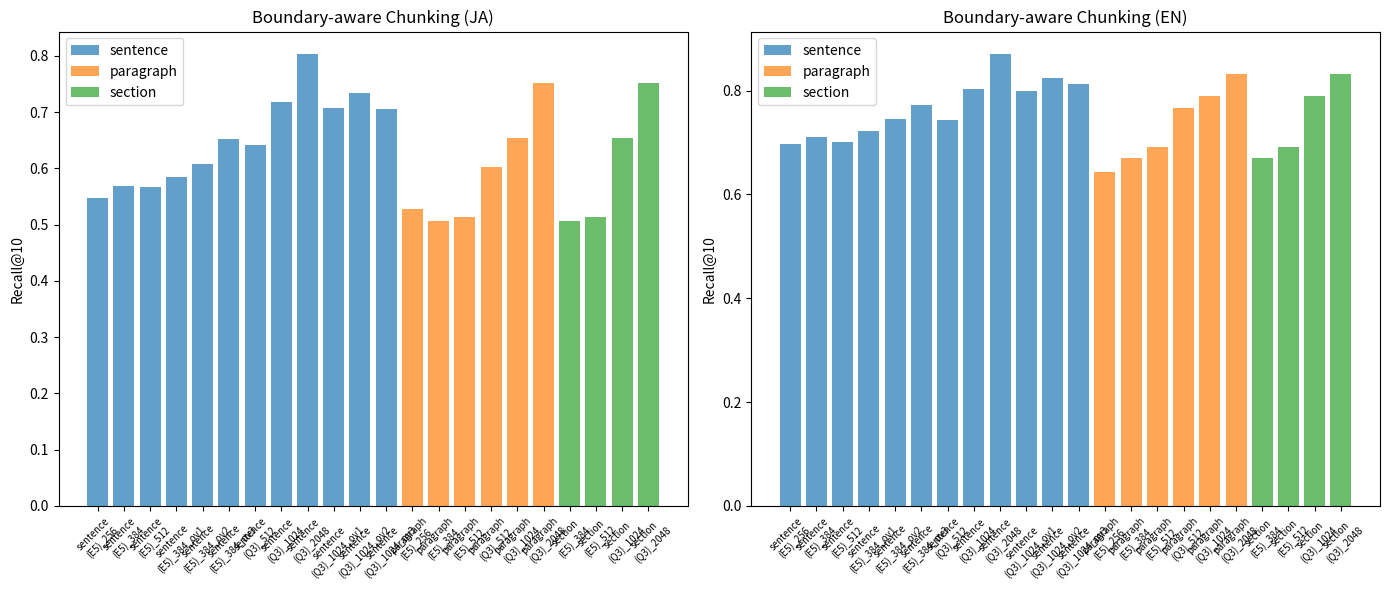

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, lang in zip(axes, ["ja", "en"]):
    # 103 results by strategy type
    for st_type in ["sentence", "paragraph", "section"]:
        subset = df[(df["lang"] == lang) & (df["strategy_type"] == st_type)]
        if not subset.empty:
            ax.bar(
                [f"{r['strategy'].replace('_e5', '\n(E5)').replace('_qwen', '\n(Q3)')}"
                 for _, r in subset.iterrows()],
                subset["Recall@10"],
                alpha=0.7, label=st_type
            )

    ax.set_ylabel("Recall@10")
    ax.set_title(f"Boundary-aware Chunking ({lang.upper()})")
    ax.legend()
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "103_boundary_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. 定性分析: サンプル記事のチャンク分割

In [14]:
# サンプル10記事のチャンク分割を表示
sample_articles = articles_ja[:10]

for art in sample_articles[:3]:
    print(f"\n{'='*60}")
    print(f"Article: {art['title']} ({len(art['text'])} chars, {len(art['paragraphs'])} paragraphs)")
    print(f"{'='*60}")

    for strategy_name, fn in [
        ("Sentence (384tok)", lambda t: chunk_by_sentence(t, tokenizer_e5, 384, 0, "ja")),
        ("Paragraph (384tok)", lambda t: chunk_by_paragraph(t, tokenizer_e5, 384, "ja")),
        ("Section (384tok)", lambda t: chunk_by_section(t, tokenizer_e5, 384, "ja")),
    ]:
        chunks = fn(art["text"])
        print(f"\n  {strategy_name}: {len(chunks)} chunks")
        for i, chunk in enumerate(chunks[:3]):
            tokens = len(tokenizer_e5.encode(chunk, add_special_tokens=False))
            print(f"    Chunk {i}: {tokens} tokens - {chunk[:80]}...")
        if len(chunks) > 3:
            print(f"    ... and {len(chunks) - 3} more chunks")

Token indices sequence length is longer than the specified maximum sequence length for this model (1572 > 512). Running this sequence through the model will result in indexing errors



Article: アンパサンド (2707 chars, 20 paragraphs)

  Sentence (384tok): 5 chunks
    Chunk 0: 355 tokens - アンパサンド（&, ）は、並立助詞「…と…」を意味する記号である。ラテン語で「…と…」を表す接続詞 "et" の合字を起源とする。現代のフォントでも、Trebu...
    Chunk 1: 358 tokens - 古ローマ筆記体では、E と T はしばしば合字として繋げて書かれていた（左図「アンパサンドの変遷」の字形1）。それに続く、流麗さを増した新ローマ筆記体では、さま...
    Chunk 2: 338 tokens - 1863年の M. B. Moore の著書 The Dixie Primer, for the Little Folks にその一例を見ることができる。ジョー...
    ... and 2 more chunks

  Paragraph (384tok): 5 chunks
    Chunk 0: 336 tokens - アンパサンド（&, ）は、並立助詞「…と…」を意味する記号である。ラテン語で「…と…」を表す接続詞 "et" の合字を起源とする。現代のフォントでも、Trebu...
    Chunk 1: 293 tokens - アンパサンドの起源は1世紀の古ローマ筆記体にまでさかのぼることができる。古ローマ筆記体では、E と T はしばしば合字として繋げて書かれていた（左図「アンパサン...
    Chunk 2: 233 tokens - アンパサンドはしばしばラテンアルファベットの最後の文字とされることがあった。たとえば1011年のByrhtferthの文字表がその例である。同様に、"&" は英...
    ... and 2 more chunks

  Section (384tok): 5 chunks
    Chunk 0: 336 tokens - アンパサンド（&, ）は、並立助詞「…と…」を意味する記号である。ラテン語で「…と…」を表す接続詞 "et" の合字を起源とする。現代のフォントでも、Trebu...
    Chunk 1: 293 tokens - アンパサンドの起源は1世紀の

## まとめ

In [15]:
print("=== 全戦略のランキング (Recall@10) ===\n")
for lang in ["ja", "en"]:
    print(f"--- {lang.upper()} ---")
    subset = df[df["lang"] == lang].sort_values("Recall@10", ascending=False)
    for i, (_, row) in enumerate(subset.head(10).iterrows()):
        print(f"  {i+1}. {row['strategy']}: R@10={row['Recall@10']:.4f}, "
              f"MRR={row['MRR']:.4f}, chunks={int(row['n_chunks'])}")
    print()

=== 全戦略のランキング (Recall@10) ===

--- JA ---
  1. sentence_qwen_2048: R@10=0.8031, MRR=0.8780, chunks=3291
  2. section_qwen_2048: R@10=0.7521, MRR=0.8564, chunks=3769
  3. paragraph_qwen_2048: R@10=0.7521, MRR=0.8564, chunks=3769
  4. sentence_qwen_1024_ov2: R@10=0.7343, MRR=0.8719, chunks=7087
  5. sentence_qwen_1024: R@10=0.7186, MRR=0.8452, chunks=6710
  6. sentence_qwen_1024_ov1: R@10=0.7070, MRR=0.8577, chunks=6897
  7. sentence_qwen_1024_ov3: R@10=0.7061, MRR=0.8626, chunks=7316
  8. paragraph_qwen_1024: R@10=0.6549, MRR=0.8149, chunks=8050
  9. section_qwen_1024: R@10=0.6549, MRR=0.8149, chunks=8050
  10. sentence_e5_384_ov3: R@10=0.6522, MRR=0.9203, chunks=20555

--- EN ---
  1. sentence_qwen_2048: R@10=0.8704, MRR=0.8849, chunks=2856
  2. section_qwen_2048: R@10=0.8326, MRR=0.8488, chunks=3025
  3. paragraph_qwen_2048: R@10=0.8326, MRR=0.8488, chunks=3025
  4. sentence_qwen_1024_ov2: R@10=0.8236, MRR=0.8786, chunks=5989
  5. sentence_qwen_1024_ov3: R@10=0.8127, MRR=0.8773, chunk

## 7. 評価・考察

### NB102（固定長）vs NB103（境界認識）の比較

| モデル | 言語 | 102 最良 (固定長) | 103 最良 (境界認識) | 差分 |
|--------|------|------------------|-------------------|------|
| E5-base | JA | **0.681** (256/ov64) | 0.652 (sentence 384 ov3) | −0.029 |
| E5-base | EN | **0.791** (384/ov128) | 0.773 (sentence 384 ov3) | −0.018 |
| Qwen3 | JA | **0.808** (2048/ov256) | 0.803 (sentence 2048) | −0.005 |
| Qwen3 | EN | **0.877** (2048/ov256) | 0.870 (sentence 2048) | −0.007 |

**固定長チャンキングが全条件で境界認識を上回った。** 境界認識チャンキングによる Recall@10 改善は確認できなかった。

### 戦略別の傾向

#### 1. 文グリーディ (sentence)
- 境界認識戦略の中では最良。オーバーラップ文数を増やすと改善するが、固定長トークンオーバーラップほどの効果はない。
- E5 (384tok): ov0→ov1 +1.6pp, ov1→ov2 +2.3pp, ov2→ov3 +4.4pp (JA)。文単位オーバーラップは文長のばらつきにより重複トークン量が不均一になる。
- Qwen3 (1024tok): ov2 が JA/EN とも最良（JA: 0.734, EN: 0.824）。ov3 で逆に低下する場合あり。

#### 2. 段落ベース (paragraph)
- 全条件で文グリーディより劣る（E5 JA: 0.506–0.528、Qwen3 EN: 0.767–0.833）。
- 段落長のばらつきが大きく、短すぎるチャンク（情報不足）と長すぎるチャンク（トピック混在）が混在する。

#### 3. セクション考慮 (section)
- **段落ベースと完全に同一の結果**。Wikipedia テキストから `== 見出し ==` マークアップが除去された状態で保存されているため、セクション分割が機能していない。セクション戦略を活かすにはNB101のデータ準備段階でマークアップを保持する必要がある。

### 固定長が優位な理由の考察

1. **均一なオーバーラップ量**: 固定長の overlap=64 や 128 トークンは常に一定量の文脈を次チャンクに引き継ぐ。文単位オーバーラップは文長に依存し、短い文1つでは数トークンしか重複しない。
2. **チャンクサイズの均一性**: 固定長はすべてのチャンクがほぼ同一トークン数。文・段落ベースではチャンク長のばらつきが大きく、短いチャンクの embedding 品質が低下する。
3. **評価タスクとの適合**: 本実験の「同一記事内チャンクの検索」タスクでは、均一な粒度で記事を網羅的にカバーする固定長が有利。実用的な QA タスク（質問に対する正解段落の検索）では境界認識が優位になる可能性がある。

### NB104 以降への示唆

- **チャンキング戦略は固定長 + トークンオーバーラップを基準とする**。E5: 256/64, Qwen3: 512/128 or 1024/128。
- セクション戦略を再検証するなら、NB101 でマークアップ付きテキストを保持する修正が必要。
- 境界認識の真の効果を測るには、QA ペアを用いた評価（質問→正解チャンク検索）が望ましい。同一記事内チャンク検索は粒度の均一性に有利なバイアスがある。